# Reweighting a STARLING ensemble against experimental SAXS with `BMECustom`

This notebook shows how to use **`soursop.ssbme.BMECustom`** to derive per-conformer
weights that bring a computed ensemble into agreement with an experimental SAXS
scattering profile.

The ingredients (all in this directory):

| file | what it is |
|------|------------|
| `pnt.dat` | the **experimental** SAXS profile (`q`, `I(q)`, `σ(I)`) |
| `saxs_frames/frame_*.dat` | one **computed** scattering curve **per conformer** (`q`, `I(q)`) |
| `pnt_STARLING.pdb` / `.xtc` | the STARLING-generated conformational ensemble |
| `average_scattering.dat` | the (uniform) ensemble-average computed profile, for reference |

**The idea.** Each conformer `i` has a computed scattering curve. The ensemble-average
curve is `⟨I(q)⟩ = Σ_i w_i I_i(q)`. With uniform weights `w_i = 1/N` this is just the plain
average; `BMECustom` instead finds the weights that best match experiment while staying
as close as possible to the uniform prior (a maximum-entropy / Bayesian-ensemble-refinement
criterion). It minimises

$$\mathcal{L}(w) = \text{cost}(w) + \theta\, D_{\mathrm{KL}}(w\,\|\,w^0)$$

directly over the `N` frame weights. `θ` trades off fit quality against how far the weights
are allowed to drift from uniform.

**Why `BMECustom` and not plain `BME` here?** SAXS intensities have an arbitrary overall
scale (instrument/units), so the computed and experimental curves live on very different
scales. `BMECustom` accepts an arbitrary `cost_function`, which lets us fold the unknown
scale directly into the goodness-of-fit — something the closed-form `BME` cannot do.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import glob

import numpy as np
import matplotlib.pyplot as plt

from soursop.ssbme import BMECustom
from soursop.sstrajectory import SSTrajectory

# This notebook reads the data files that sit alongside it.
DATA_DIR = Path(".")
SAXS_FRAME_DIR = DATA_DIR / "saxs_frames"

## 1. Load the experimental scattering profile

`pnt.dat` has three columns: `q` (Å⁻¹), `I(q)`, and the experimental uncertainty `σ(I)`.

In [2]:
exp = np.loadtxt(DATA_DIR / "pnt.dat")
q_exp, I_exp_raw, sigma_exp_raw = exp[:, 0], exp[:, 1], exp[:, 2]
print(f"experimental SAXS: {q_exp.size} q-points, "
      f"q = {q_exp.min():.4f} - {q_exp.max():.4f} 1/A")

experimental SAXS: 1268 q-points, q = 0.0048 - 0.3807 1/A


## 2. Load the per-frame computed scattering

Each `frame_*.dat` is the computed profile for one conformer, all on the **same** computed
`q`-grid. We stack them into the `(n_frames, m)` matrix that `BMECustom` expects as
`calculated_values` — one row per conformer, one column per `q`-point.

In [3]:
frame_files = sorted(glob.glob(str(SAXS_FRAME_DIR / "frame_*.dat")))
q_calc = np.loadtxt(frame_files[0])[:, 0]                       # shared computed q-grid
calc = np.array([np.loadtxt(f)[:, 1] for f in frame_files])     # (n_frames, m_calc)
n_frames = calc.shape[0]

print(f"loaded {n_frames} per-frame profiles on {q_calc.size} q-points")
print(f"calculated_values matrix shape (n_frames, m): {calc.shape}")

loaded 600 per-frame profiles on 100 q-points
calculated_values matrix shape (n_frames, m): (600, 100)


## 3. Put experiment and computation on a common grid

The experimental and computed `q`-grids differ, so we interpolate the experimental curve
onto the computed grid, restricted to the overlapping `q`-range. We then look at the two
curves side by side — note the large difference in absolute intensity scale.

In [4]:
mask = (q_calc >= q_exp.min()) & (q_calc <= q_exp.max())
q = q_calc[mask]
I_exp = np.interp(q, q_exp, I_exp_raw)
sigma_exp = np.interp(q, q_exp, sigma_exp_raw)
C = calc[:, mask]                         # (n_frames, m) computed matrix on the common grid

avg_prior = C.mean(axis=0)               # uniform-weight ensemble average

print(f"common grid: {q.size} q-points, q = {q.min():.4f} - {q.max():.4f} 1/A")
print(f"intensity scale: <I_calc> ~ {avg_prior[0]:.3g},  I_exp ~ {I_exp[0]:.3g}  "
      f"(ratio ~ {avg_prior[0] / I_exp[0]:.0f}x)")

common grid: 76 q-points, q = 0.0050 - 0.3800 1/A
intensity scale: <I_calc> ~ 6.82e+05,  I_exp ~ 873  (ratio ~ 781x)


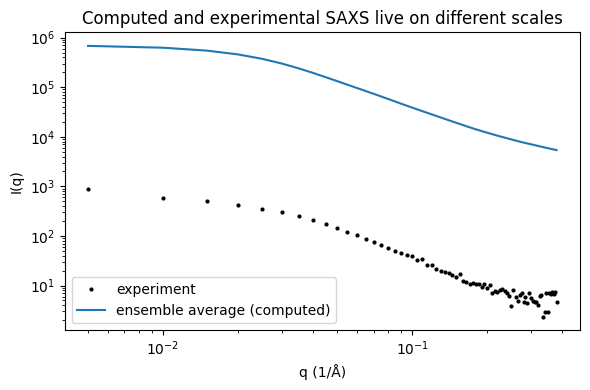

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(q, I_exp, "k.", ms=4, label="experiment")
ax.loglog(q, avg_prior, "C0-", label="ensemble average (computed)")
ax.set_xlabel("q (1/\u00c5)")
ax.set_ylabel("I(q)")
ax.set_title("Computed and experimental SAXS live on different scales")
ax.legend()
fig.tight_layout()

## 4. A SAXS-aware cost function

Because the absolute scale is arbitrary, a fair goodness-of-fit must compare *shapes*, not
absolute intensities. For any candidate ensemble average `avg = w @ C` the best-fit
multiplicative scale `α` has a closed form (weighted least squares against the experimental
errors):

$$\alpha^\* = \frac{\sum_k \mathrm{avg}_k\, I^{\mathrm{exp}}_k / \sigma_k^2}{\sum_k \mathrm{avg}_k^2 / \sigma_k^2}$$

We marginalise `α` inside the cost, so the reduced χ² it returns is scale-invariant. This is
exactly the kind of bespoke goodness-of-fit `BMECustom` is designed for: it is called as
`cost_function(experiment, calculated_values, weights) -> float` (lower is better).

In [6]:
def optimal_scale(avg, experiment, sigma):
    """Least-squares multiplicative scale bringing `avg` onto `experiment`."""
    return np.sum(avg * experiment / sigma**2) / np.sum(avg**2 / sigma**2)


def saxs_chi2(experiment, calculated_values, weights):
    """Reduced chi^2 between the weighted average and experiment, with the
    overall SAXS scale marginalised analytically."""
    avg = weights @ calculated_values
    alpha = optimal_scale(avg, experiment, sigma_exp)
    return float(np.mean(((alpha * avg - experiment) / sigma_exp) ** 2))

## 5. Build `BMECustom` and fit

We pass the experimental vector, the per-frame matrix, and our custom cost. With no
`initial_weights` the prior is uniform. A first fit at `θ = 10` (a moderately conservative
penalty) shows the cost dropping while a large fraction of the ensemble is retained
(`phi`, the effective fraction of frames).

In [7]:
bme = BMECustom(I_exp, C, cost_function=saxs_chi2)
result = bme.fit(theta=10.0)
print()
print(result)

BMECustom Optimization
  Frames: 600, Observables (vector length): 76
  Cost function: custom
  Theta: 10.0
  Cost initial: 4.4026


  Cost final: 2.0503
  Effective fraction (phi): 0.9181
  Optimization successful: True
  Optimizer message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

BMECustom Result [SUCCESS]
  Cost initial: 4.4026
  Cost final:   2.0503
  phi (effective fraction): 0.9181
  Iterations: 16
  Theta: 10.0


## 6. Choose `θ` with an L-curve scan

Rather than picking `θ` by hand, scan a range and take the knee of the L-curve (cost vs.
how far the weights have moved from the prior, `D_KL`). The knee is the point of
diminishing returns: below it, fit quality barely improves but the ensemble is distorted
more and more.

In [8]:
scan = bme.scan_theta(theta_range=(0.1, 1000.0), n_points=12, verbose=False)
print(f"selected theta (L-curve knee): {scan.optimal_theta:.3g}")

selected theta (L-curve knee): 2.85


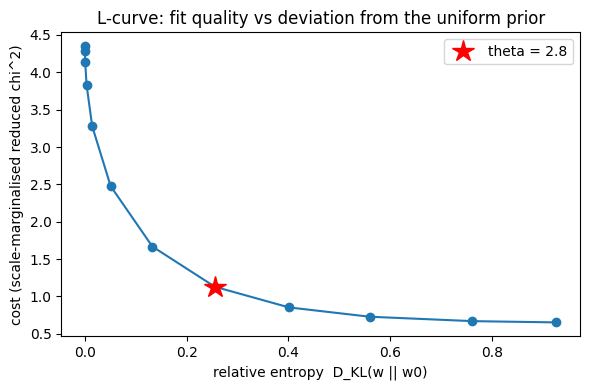

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(scan.kl_divergence_values, scan.chi_squared_values, "o-")
ax.plot(scan.kl_divergence_values[scan.optimal_idx],
        scan.chi_squared_values[scan.optimal_idx],
        "r*", ms=16, label=f"theta = {scan.optimal_theta:.2g}")
ax.set_xlabel("relative entropy  D_KL(w || w0)")
ax.set_ylabel("cost (scale-marginalised reduced chi^2)")
ax.set_title("L-curve: fit quality vs deviation from the uniform prior")
ax.legend()
fig.tight_layout()

In [10]:
# refit at the selected theta
result = bme.fit(theta=scan.optimal_theta, verbose=False)
print(result)
print(f"\nphi (effective fraction of frames kept): {result.phi:.3f}  "
      f"-> ~{result.phi * n_frames:.0f}/{n_frames} frames")

BMECustom Result [SUCCESS]
  Cost initial: 4.4026
  Cost final:   1.1295
  phi (effective fraction): 0.7746
  Iterations: 18
  Theta: 2.848035868435802

phi (effective fraction of frames kept): 0.775  -> ~465/600 frames


## 7. Did it work? Reweighted average vs experiment

Compare the **prior** (uniform-average) computed profile and the **reweighted** average
against the experimental data, each shown at its own best-fit scale. The lower panel shows
the per-point residuals in units of `σ`.

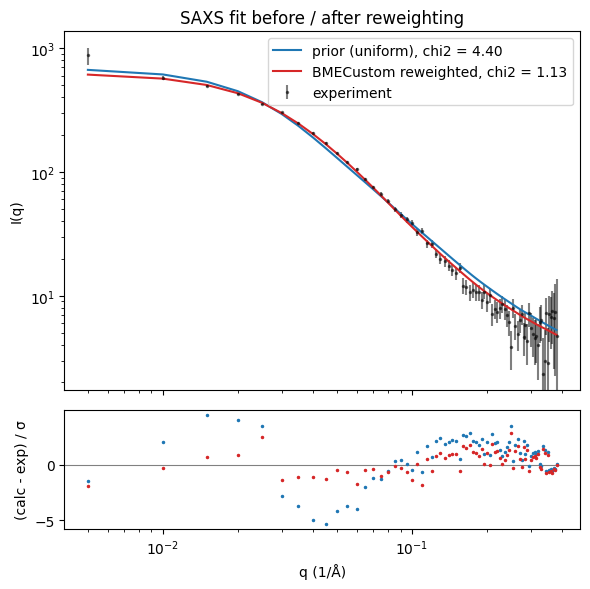

In [11]:
avg_pr = result.initial_weights @ C          # uniform prior average
avg_rw = result.weights @ C                  # BMECustom reweighted average
a_pr = optimal_scale(avg_pr, I_exp, sigma_exp)
a_rw = optimal_scale(avg_rw, I_exp, sigma_exp)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(6, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

ax1.errorbar(q, I_exp, yerr=sigma_exp, fmt="k.", ms=3, alpha=0.5, label="experiment")
ax1.plot(q, a_pr * avg_pr, "C0-", label=f"prior (uniform), chi2 = {result.cost_initial:.2f}")
ax1.plot(q, a_rw * avg_rw, "C3-", label=f"BMECustom reweighted, chi2 = {result.cost_final:.2f}")
ax1.set_yscale("log")
ax1.set_ylabel("I(q)")
ax1.set_title("SAXS fit before / after reweighting")
ax1.legend()

ax2.axhline(0, color="gray", lw=0.8)
ax2.plot(q, (a_pr * avg_pr - I_exp) / sigma_exp, "C0.", ms=3, label="prior")
ax2.plot(q, (a_rw * avg_rw - I_exp) / sigma_exp, "C3.", ms=3, label="reweighted")
ax2.set_xscale("log")
ax2.set_xlabel("q (1/\u00c5)")
ax2.set_ylabel("(calc - exp) / \u03c3")
fig.tight_layout()

## 8. Inspect the weights

The posterior weights tell us which conformers experiment prefers. `print_diagnostics()`
summarises the effective sample size and flags any over-fitting (a `phi` that has collapsed
to a handful of frames).


BME (custom) DIAGNOSTIC REPORT

Optimization Status: STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT
Success: True
Iterations: 18

Cost:
  Initial                                  4.4026
  Final                                    1.1295
  Improvement                              3.2731

Ensemble diversity:
  Phi (entropy fraction)                   0.7746
  N_eff (entropy-based)                     464.7  / 600
  N_eff (1/sum w^2, Renyi-2)                323.2  / 600
  Theta                                    2.8480

Status: OK - No issues detected


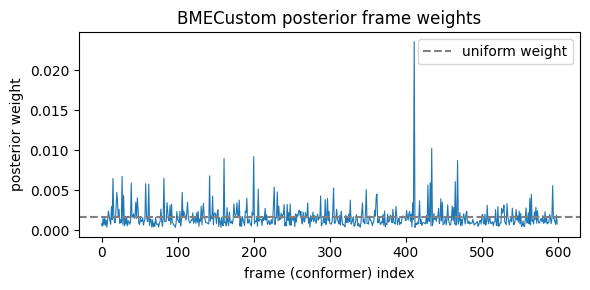

In [12]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(result.weights, lw=0.8)
ax.axhline(1.0 / n_frames, color="gray", ls="--", label="uniform weight")
ax.set_xlabel("frame (conformer) index")
ax.set_ylabel("posterior weight")
ax.set_title("BMECustom posterior frame weights")
ax.legend()
fig.tight_layout()

result.print_diagnostics()

## 9. Use the weights with the rest of SOURSOP

The weights are just a per-frame probability vector, so they plug directly into any
SOURSOP observable via the package-wide `weights=` argument. The SAXS-derived weights are
in the same order as the conformers (`frame_00000.dat` ↔ trajectory frame 0), so they line
up 1:1 with the loaded trajectory. Here we look at how reweighting reshapes the radius of
gyration distribution.

In [13]:
traj = SSTrajectory(str(DATA_DIR / "pnt_STARLING.xtc"), str(DATA_DIR / "pnt_STARLING.pdb"))
protein = traj.proteinTrajectoryList[0]
assert protein.n_frames == n_frames, "trajectory frames must align 1:1 with the SAXS frames"

rg = protein.get_radius_of_gyration()                              # per-frame Rg, (n_frames,)
rg_prior = float(np.mean(rg))
rg_reweighted = protein.get_radius_of_gyration(weights=result.weights)   # weighted mean

print(f"<Rg> prior (uniform):   {rg_prior:.2f} A")
print(f"<Rg> SAXS-reweighted:   {rg_reweighted:.2f} A")

<Rg> prior (uniform):   57.10 A
<Rg> SAXS-reweighted:   52.91 A


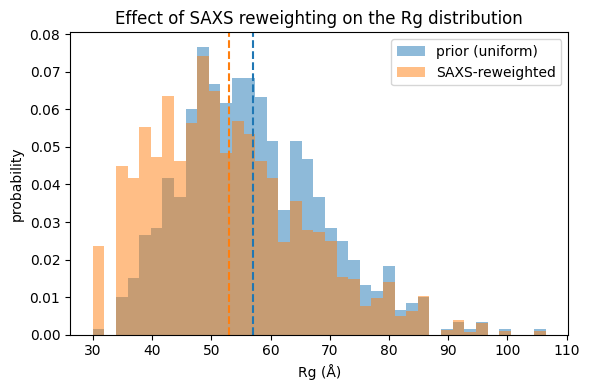

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
bins = np.linspace(rg.min(), rg.max(), 40)
ax.hist(rg, bins=bins, weights=np.full(n_frames, 1.0 / n_frames),
        alpha=0.5, label="prior (uniform)")
ax.hist(rg, bins=bins, weights=result.weights,
        alpha=0.5, label="SAXS-reweighted")
ax.axvline(rg_prior, color="C0", ls="--")
ax.axvline(rg_reweighted, color="C1", ls="--")
ax.set_xlabel("Rg (\u00c5)")
ax.set_ylabel("probability")
ax.set_title("Effect of SAXS reweighting on the Rg distribution")
ax.legend()
fig.tight_layout()

## Notes and caveats

- **Validate, don't just fit.** A lower χ² is only meaningful if `phi` (the effective
  fraction of frames) stays reasonable. A great-looking fit with `phi → 0` means a few
  conformers are carrying all the weight — that is over-fitting, not agreement. Increase
  `θ` (or loosen the errors) if `phi` collapses.
- **`θ` selection.** The L-curve knee is a sensible default, but inspect the curve: if the
  cost barely changes across the whole scan, the prior already agrees with the data and
  reweighting is unnecessary.
- **Scale (and offset).** We marginalised a single multiplicative scale. If your data also
  carry a constant background you can extend `saxs_chi2` to fit a scale **and** offset
  (a 2-parameter linear least squares) — the beauty of `BMECustom` is that any such
  goodness-of-fit drops straight in. If instead the scale is *known*, you can pre-scale the
  computed curves and use plain `BME` / `iBME`.
- **Frame alignment.** The weight vector is ordered like `calculated_values` (and the
  trajectory). Keep that order fixed whenever you reuse the weights downstream.
- **`predict()`.** `result.predict(some_other_per_frame_matrix)` applies the same weights
  to an independent observable computed per frame — handy for cross-validating against data
  that were *not* used in the fit.